In [1]:
!pip install xgboost shap

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from google.colab import files
uploaded = files.upload()

Saving materials_ml.parquet to materials_ml.parquet


In [4]:
import pandas as pd

df = pd.read_parquet("materials_ml.parquet")

print(df.shape)
df.head()

(20001, 17)


,material_id,band_gap,energy,cohesive_energy,space_group,volume,density,nsites,Z_mean,Z_max,Z_var,num_elements,SOC_proxy,EN_range,magmom,is_metal,is_magnetic
0,matpes-20240214_999485_2,0.0,-16.832872,-2.481338,1,22.207064,5.938330,2,18.5,30,132.25,2,406200.5,1.39,0.001,True,False
1,matpes-20240214_999484_70,0.0,-31.680919,-3.805109,1,49.736736,4.566377,2,30.5,39,72.25,2,1273848.5,0.32,1.700,True,True
2,matpes-20240214_999484_47,0.0,-32.384422,-4.156860,8,50.392076,4.506992,2,30.5,39,72.25,2,1273848.5,0.32,1.829,True,True
3,matpes-20240214_999484_26,0.0,-31.967042,-3.948170,1,48.717972,4.661866,2,30.5,39,72.25,2,1273848.5,0.32,-2.059,True,False
4,matpes-20240214_999484_13,0.0,-31.691182,-3.810240,1,52.719232,4.308042,2,30.5,39,72.25,2,1273848.5,0.32,2.245,True,True


In [6]:
features = [
    "energy",
    "cohesive_energy",
    "volume",
    "density",
    "nsites",
    "space_group",
    "Z_mean",
    "Z_max",
    "Z_var",
    "num_elements",
    "SOC_proxy",
    "EN_range",
    "magmom"
]

X = df[features]
y = df["is_metal"]

In [7]:
print(X.shape)
print(y.shape)
print(X.columns)

(20001, 13)
(20001,)
Index(['energy', 'cohesive_energy', 'volume', 'density', 'nsites',
       'space_group', 'Z_mean', 'Z_max', 'Z_var', 'num_elements', 'SOC_proxy',
       'EN_range', 'magmom'],
      dtype='object')


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=400,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=400, n_jobs=-1,
                       random_state=42)

In [10]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

       False       0.86      0.64      0.74       345
        True       0.97      0.99      0.98      3656

    accuracy                           0.96      4001
   macro avg       0.91      0.82      0.86      4001
weighted avg       0.96      0.96      0.96      4001


ROC-AUC: 0.9732613452573495

Confusion Matrix:

[[ 222  123]
 [  36 3620]]


In [11]:
import pandas as pd

importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print(importance)

            feature  importance
3           density    0.226583
11         EN_range    0.198915
2            volume    0.092138
6            Z_mean    0.084290
0            energy    0.068055
1   cohesive_energy    0.066393
10        SOC_proxy    0.066053
12           magmom    0.057059
7             Z_max    0.053860
8             Z_var    0.049557
5       space_group    0.018113
4            nsites    0.010930
9      num_elements    0.008054


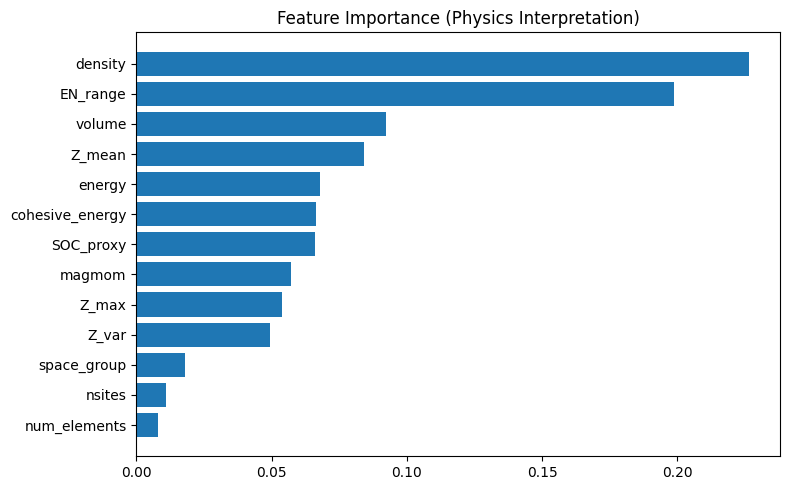

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(importance["feature"], importance["importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance (Physics Interpretation)")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300)
plt.show()

In [13]:
df["is_semimetal"] = (df["band_gap"] < 0.2) & (df["is_metal"] == False)

In [15]:
df["is_topology_candidate"] = (
    (df["space_group"] > 0) &
    (df["SOC_proxy"] > df["SOC_proxy"].quantile(0.7)) &
    (df["EN_range"] > 0.5)
)

In [17]:
import numpy as np
df["symmetry_entropy"] = np.log1p(df["space_group"])

In [19]:
df["SOC_bond_coupling"] = df["SOC_proxy"] * df["EN_range"]

In [21]:
df["lattice_rigidity"] = df["density"] / (df["volume"] + 1e-6)

In [23]:
df["chemical_imbalance"] = (df["Z_max"] - df["Z_mean"]) / (df["Z_mean"] + 1e-6)

In [24]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

features = [
    "SOC_proxy",
    "EN_range",
    "space_group",
    "density",
    "volume",
    "Z_mean",
    "Z_var",
    "symmetry_entropy",
    "SOC_bond_coupling",
    "lattice_rigidity",
    "chemical_imbalance"
]

X = df[features]
y = df["is_semimetal"]   # start simple first

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

model = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=10,   # tune later
    eval_metric="logloss"
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=None,
              num_parallel_tree=None, ...)

In [25]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.99      0.99      0.99      3964
        True       0.12      0.08      0.10        37

    accuracy                           0.99      4001
   macro avg       0.56      0.54      0.54      4001
weighted avg       0.98      0.99      0.98      4001

ROC-AUC: 0.7964041235988764
[[3942   22]
 [  34    3]]


In [26]:
import pandas as pd

fi = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print(fi)

               feature  importance
1             EN_range    0.172158
9     lattice_rigidity    0.130753
8    SOC_bond_coupling    0.102003
6                Z_var    0.098912
3              density    0.095982
5               Z_mean    0.095134
4               volume    0.082903
0            SOC_proxy    0.081578
10  chemical_imbalance    0.079186
2          space_group    0.061392
7     symmetry_entropy    0.000000


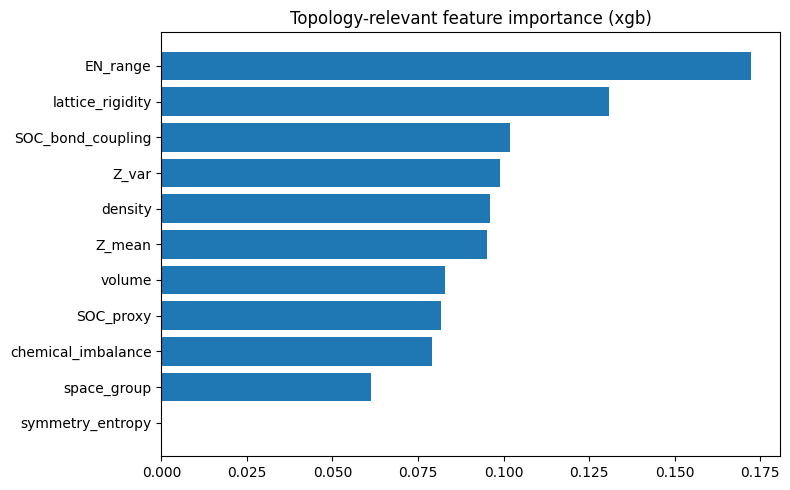

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(fi["feature"], fi["importance"])
plt.gca().invert_yaxis()
plt.title("Topology-relevant feature importance (xgb)")
plt.tight_layout()
plt.savefig("feature_importance_xgb.png", dpi=300)
plt.show()